In [4]:
#  Imports and Paths

import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 300)

MIMIC = Path("data/mimic-iv")
NOTES = Path("data/mimic-iv-note")


In [6]:
# Load diagnoses

diagnoses = pd.read_csv(
    MIMIC / "hosp/diagnoses_icd.csv.gz",
    usecols=["hadm_id", "icd_code", "icd_version"]
)

In [8]:
# Keep ICD-10 only

diagnoses = diagnoses[diagnoses["icd_version"] == 10]
diagnoses.head()


,hadm_id,icd_code,icd_version
40,23052089,G3183,10
41,23052089,F0280,10
42,23052089,R441,10
43,23052089,R296,10
44,23052089,E785,10


In [10]:
# Load discharge summaries

notes = pd.read_csv(
    NOTES / "note/discharge.csv.gz",
    usecols=["hadm_id", "text"]
)

notes = notes.dropna(subset=["text"])
notes.head()


,hadm_id,text
0,22595853,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: F\n \nService: MEDICINE\n \nAllergies: \nNo Known Allergies / Adverse Drug Reactions\n \nAttending: ___\n \nChief Complaint:\nWorsening ABD dist...
1,22841357,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: F\n \nService: MEDICINE\n \nAllergies: \nPercocet\n \nAttending: ___.\n \nChief Complaint:\nabdominal fullness and discomfort\n \nMajor Surgical...
2,29079034,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: F\n \nService: MEDICINE\n \nAllergies: \nPercocet / Vicodin\n \nAttending: ___\n \nChief Complaint:\naltered mental status\n \nMajor Surgical or...
3,25742920,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: F\n \nService: MEDICINE\n \nAllergies: \nPercocet / Vicodin\n \nAttending: ___.\n \nChief Complaint:\nAbdominal pain\n \nMajor Surgical or Invas...
4,23052089,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: M\n \nService: MEDICINE\n \nAllergies: \nNo Known Allergies / Adverse Drug Reactions\n \nAttending: ___.\n \nChief Complaint:\nVisual hallucinati...


In [11]:
# Inspect Basic Counts (Sanity Check)

print("Total discharge summaries:", notes["hadm_id"].nunique())
print("Total ICD-10 diagnosis rows:", diagnoses.shape[0])
print("Unique ICD-10 codes:", diagnoses["icd_code"].nunique())


Total discharge summaries: 331793
Total ICD-10 diagnosis rows: 3455747
Unique ICD-10 codes: 19440


In [12]:
# Build Admission Level ICD Labels

labels = (
    diagnoses
    .groupby("hadm_id")["icd_code"]
    .apply(list)
    .reset_index()
)

labels.head()


,hadm_id,icd_code
0,20000024,"[D500, K521, I10, E538, M810, R270, Z9181, H548, T474X5A, Y92099]"
1,20000034,"[K831, K8689, K861, K869, R1032, R10819, R8279, J439, E1122, I129, N183, K7030, Z794, E43, Z681, Z85118, E83119, Z8673, M4800, R270, N400, E871, Z86718, R339, G4700, D509, F09, Z87891]"
2,20000045,"[A419, N390, C7951, C787, K56699, C779, K5100, B9620, K1230, D630, C679, E8339, Z87891, Z8616, G893, D6481]"
3,20000069,"[O701, Z370, Z3A37]"
4,20000094,"[I509, K7200, R570, N179, I2510, Z9861, I255, E785, E118, E669, I129, N189, J449, R7989, I4891, Z515, Z66, I447, I340, I272, I071]"


In [13]:
#  Merge Notes + Labels

dataset = notes.merge(labels, on="hadm_id", how="inner")

dataset.head()


,hadm_id,text,icd_code
0,23052089,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: M\n \nService: MEDICINE\n \nAllergies: \nNo Known Allergies / Adverse Drug Reactions\n \nAttending: ___.\n \nChief Complaint:\nVisual hallucinati...,"[G3183, F0280, R441, R296, E785, Z8546]"
1,22927623,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: F\n \nService: MEDICINE\n \nAllergies: \nomeprazole\n \nAttending: ___.\n \nChief Complaint:\ndysphagia \n \nMajor Surgical or Invasive Procedure:\n...,"[R1310, R0989, K31819, K219, K449, F419, I341, M810, Z87891]"
2,27988844,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: F\n \nService: ORTHOPAEDICS\n \nAllergies: \nomeprazole / Iodine and Iodide Containing Products / \nhallucinogens\n \nAttending: ___.\n \nChief Comp...,"[S72012A, W010XXA, Y93K1, Y92480, K219, E7800, I341, G43909, Z87891, Z87442, F419, M810, Z7901]"
3,25911675,"\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: F\n \nService: MEDICINE\n \nAllergies: \nNo Known Allergies / Adverse Drug Reactions\n \nAttending: ___.\n \nChief Complaint:\nfatigue, anemia\n \nMajor Su...","[D500, I5023, N184, E118, K2970, Z23, K259, K5730, I2510, Z87891, I252, Z955, I129, Z794, Z8673, R0789, Z86718, R791, T45515A, I70218, K222, K219]"
4,29659838,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: F\n \nService: MEDICINE\n \nAllergies: \nNo Known Allergies / Adverse Drug Reactions\n \nAttending: ___.\n \nChief Complaint:\ndyspnea on exertion\n \nMajo...,"[I5023, N184, D631, E1121, Z86718, I129, Z955, I2510, Z7901, Z794, I340, I252, Z8673, Z87891, Z91128, E785]"


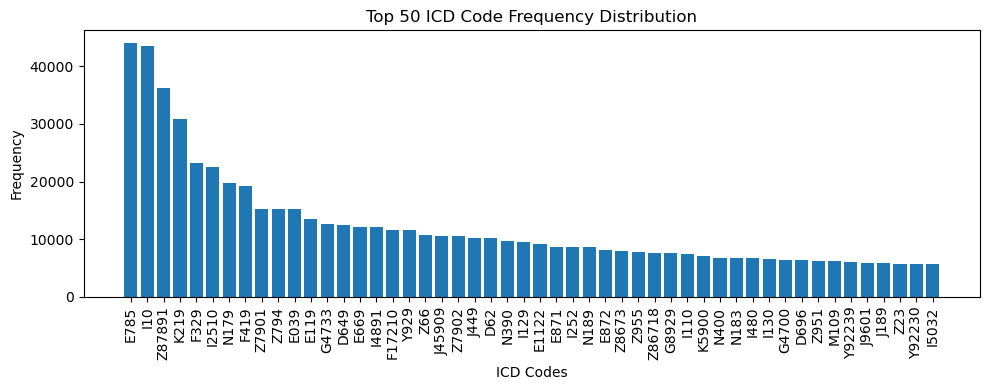

In [26]:
from collections import Counter
import matplotlib.pyplot as plt

# Flatten all codes
all_codes = [code for codes in dataset["icd_code"] for code in codes]

# Count frequencies
code_freq = Counter(all_codes)

# Get top 50 as (code, frequency) pairs
top_50 = code_freq.most_common(50)

# Split into separate lists
codes = [code for code, _ in top_50]
freqs = [freq for _, freq in top_50]

# Plot
plt.figure(figsize=(10,4))
plt.bar(codes, freqs)
plt.xticks(rotation=90)
plt.title("Top 50 ICD Code Frequency Distribution")
plt.ylabel("Frequency")
plt.xlabel("ICD Codes")
plt.tight_layout()
plt.savefig("icd_distribution.png")
plt.show()

In [28]:
# Filter dataset to top 50 codes only 

def filter_top_codes(code_list, allowed_codes):
    return [code for code in code_list if code in allowed_codes]

dataset["icd_code"] = dataset["icd_code"].apply(
    lambda x: filter_top_codes(x, top_50_codes)
)

# Drop admissions with zero remaining labels
dataset = dataset[dataset["icd_code"].map(len) > 0]


In [30]:
# Final Dataset Statistics

dataset["note_length"] = dataset["text"].str.len()
dataset["num_codes"] = dataset["icd_code"].apply(len)

summary_stats = {
    "num_admissions": dataset["hadm_id"].nunique(),
    "num_unique_codes": len(top_50_codes),
    "avg_note_length": dataset["note_length"].mean(),
    "avg_codes_per_admission": dataset["num_codes"].mean(),
    "max_note_length": dataset["note_length"].max()
}

summary_stats


{'num_admissions': 115103,
 'num_unique_codes': 50,
 'avg_note_length': 11724.312650408765,
 'avg_codes_per_admission': 5.369356141890307,
 'max_note_length': 58596}

In [32]:
# Save Final Modeling Dataset

dataset_final = dataset[["hadm_id", "text", "icd_code"]]

dataset_final.to_parquet("final_modeling_dataset.parquet")


In [33]:
# Final Sanity Check

dataset_final.sample(3)


,hadm_id,text,icd_code
64191,24715229,"\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: F\n \nService: SURGERY\n \nAllergies: \nVicodin\n \nAttending: ___.\n \nChief Complaint:\nNausea, emesis\n \nMajor Surgical or Invasive Procedure:\n_...","[E872, E039]"
8032,22762017,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: M\n \nService: SURGERY\n \nAllergies: \nNo Known Allergies / Adverse Drug Reactions\n \nAttending: ___.\n \nChief Complaint:\nLeft toe ulcer\n \nMajor...,"[N179, I10, E785, Z87891, Z23]"
10395,20846888,"\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: M\n \nService: MEDICINE\n \nAllergies: \nPenicillins\n \nAttending: ___.\n \nChief Complaint:\nmelena, anemia\n \nMajor Surgical or Invasive Pr...","[D62, I4891, I10, Z7901]"
